In [3]:
import pandas as pd

df = pd.read_csv('6_live_data.csv')
df.to_parquet('6_live_data.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559 entries, 0 to 3558
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   timestamp                 3559 non-null   object
 1   node-stores               3559 non-null   int64 
 2   bus_access                3559 non-null   int64 
 3   skb_kfree_skb             3559 non-null   int64 
 4   cpu_cycles                3559 non-null   int64 
 5   l2d_cache_wb_victim       3559 non-null   int64 
 6   syscalls_sys_enter_fcntl  3559 non-null   int64 
 7   syscalls_sys_exit_fcntl   3559 non-null   int64 
 8   sched_sched_stat_runtime  3559 non-null   int64 
 9   st_spec                   3559 non-null   int64 
 10  syscalls_sys_enter_kill   3559 non-null   int64 
 11  fib_fib_table_lookup      3559 non-null   int64 
 12  sock_inet_sock_set_state  3559 non-null   int64 
 13  l2d_cache_wb              3559 non-null   int64 
 14  unaligned_st_spec       

In [4]:
df.head(-1)

,timestamp,node-stores,bus_access,skb_kfree_skb,cpu_cycles,l2d_cache_wb_victim,syscalls_sys_enter_fcntl,syscalls_sys_exit_fcntl,sched_sched_stat_runtime,st_spec,syscalls_sys_enter_kill,fib_fib_table_lookup,sock_inet_sock_set_state,l2d_cache_wb,unaligned_st_spec,mem_access_rd,l2d_cache_refill_wr,mmc_mmc_request_start,br_mis_pred
0,2025-07-30T15:48:57.226705,18887,82089,60954893,4043285,3114,23462935,23462935,23223971886754,436948,138246,396010555,268993,3114,63,635937,1505,457171,15410
1,2025-07-30T15:49:02.372257,18957,85581,60954905,4039792,3653,23467632,23467632,23227668270553,433512,138271,396010629,269042,3653,66,627200,1802,457284,15437
2,2025-07-30T15:49:07.534269,18008,86700,60954915,3841107,3057,23472381,23472381,23231555230732,435798,138297,396010693,269088,3057,65,640021,1483,457390,15848
3,2025-07-30T15:49:13.121821,17939,79881,60954922,3876611,3180,23477024,23477024,23239061900188,431309,138321,396399427,269129,3180,64,636952,1507,457496,16171
4,2025-07-30T15:49:19.001867,20599,86541,60954933,4074353,4031,23481658,23481658,23247907967981,992512,138344,396913767,269175,4031,66,628618,1866,457590,15920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,2025-07-30T21:53:13.893525,20755,88088,240470194,3990971,3944,44101513,44101513,46611724650219,427668,264908,1055357960,534736,3944,69,633332,1685,972096,24653
3554,2025-07-30T21:53:19.325867,24639,92202,240470204,8351518,6072,44105959,44105959,46620865632654,1161493,264929,1055893679,534772,6072,64,630167,2021,972192,15802
3555,2025-07-30T21:53:24.707863,20973,89492,240470219,9114852,3868,44110830,44110830,46629947369979,1054825,264952,1056426959,534829,3868,72,626013,1612,972216,15903
3556,2025-07-30T21:53:30.390922,24080,95095,240470241,4106615,3911,44120545,44120545,46648349256583,438664,264998,1057483777,534926,3911,68,1684098,1664,972264,16085


In [5]:
counter_features = [
    'skb_kfree_skb', 'syscalls_sys_enter_fcntl',
    'sched_sched_stat_runtime', 'syscalls_sys_enter_kill',
    'fib_fib_table_lookup', 'sock_inet_sock_set_state', 'mmc_mmc_request_start'
]

# Delta-Werte berechnen und Originalwerte ersetzen
for feat in counter_features:
    if feat in df.columns:
        df[feat] = df[feat].diff().fillna(0)

# Vorschau der ersetzten Features
df[counter_features].head(-1)

,skb_kfree_skb,syscalls_sys_enter_fcntl,sched_sched_stat_runtime,syscalls_sys_enter_kill,fib_fib_table_lookup,sock_inet_sock_set_state,mmc_mmc_request_start
0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
1,12.0,4697.0,3.696384e+09,25.0,74.0,49.0,113.0
2,10.0,4749.0,3.886960e+09,26.0,64.0,46.0,106.0
3,7.0,4643.0,7.506669e+09,24.0,388734.0,41.0,106.0
4,11.0,4634.0,8.846068e+09,23.0,514340.0,46.0,94.0
...,...,...,...,...,...,...,...
3553,11.0,4153.0,8.797012e+09,24.0,511106.0,48.0,52.0
3554,10.0,4446.0,9.140982e+09,21.0,535719.0,36.0,96.0
3555,15.0,4871.0,9.081737e+09,23.0,533280.0,57.0,24.0
3556,22.0,9715.0,1.840189e+10,46.0,1056818.0,97.0,48.0


In [6]:
df.head(-1)

,timestamp,node-stores,bus_access,skb_kfree_skb,cpu_cycles,l2d_cache_wb_victim,syscalls_sys_enter_fcntl,syscalls_sys_exit_fcntl,sched_sched_stat_runtime,st_spec,syscalls_sys_enter_kill,fib_fib_table_lookup,sock_inet_sock_set_state,l2d_cache_wb,unaligned_st_spec,mem_access_rd,l2d_cache_refill_wr,mmc_mmc_request_start,br_mis_pred
0,2025-07-30T15:48:57.226705,18887,82089,0.0,4043285,3114,0.0,23462935,0.000000e+00,436948,0.0,0.0,0.0,3114,63,635937,1505,0.0,15410
1,2025-07-30T15:49:02.372257,18957,85581,12.0,4039792,3653,4697.0,23467632,3.696384e+09,433512,25.0,74.0,49.0,3653,66,627200,1802,113.0,15437
2,2025-07-30T15:49:07.534269,18008,86700,10.0,3841107,3057,4749.0,23472381,3.886960e+09,435798,26.0,64.0,46.0,3057,65,640021,1483,106.0,15848
3,2025-07-30T15:49:13.121821,17939,79881,7.0,3876611,3180,4643.0,23477024,7.506669e+09,431309,24.0,388734.0,41.0,3180,64,636952,1507,106.0,16171
4,2025-07-30T15:49:19.001867,20599,86541,11.0,4074353,4031,4634.0,23481658,8.846068e+09,992512,23.0,514340.0,46.0,4031,66,628618,1866,94.0,15920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,2025-07-30T21:53:13.893525,20755,88088,11.0,3990971,3944,4153.0,44101513,8.797012e+09,427668,24.0,511106.0,48.0,3944,69,633332,1685,52.0,24653
3554,2025-07-30T21:53:19.325867,24639,92202,10.0,8351518,6072,4446.0,44105959,9.140982e+09,1161493,21.0,535719.0,36.0,6072,64,630167,2021,96.0,15802
3555,2025-07-30T21:53:24.707863,20973,89492,15.0,9114852,3868,4871.0,44110830,9.081737e+09,1054825,23.0,533280.0,57.0,3868,72,626013,1612,24.0,15903
3556,2025-07-30T21:53:30.390922,24080,95095,22.0,4106615,3911,9715.0,44120545,1.840189e+10,438664,46.0,1056818.0,97.0,3911,68,1684098,1664,48.0,16085


In [7]:
df = df.drop(columns=['syscalls_sys_exit_fcntl'])


In [9]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib

# 1. Lade das Modell und den Scaler
model = load_model('6_lstm_model_final.keras')
scaler = joblib.load("6_scaler_final.pkl")

sequence_length = 2
timestamps = df["timestamp"].iloc[sequence_length - 1:].reset_index(drop=True)
# Entferne alle nicht-numerischen Spalten (einschließlich timestamp)
df = df.drop(columns=['timestamp', 'benign_prob', 'attack_prob', 'prediction'], errors='ignore')
#df = df.drop(columns=['jbd2_jbd2_shrink_count', 'syscalls_sys_enter_fchmod'], errors='ignore')

# Skaliere die Eingabedaten
scaled_data = scaler.transform(df)

# LSTM-Sequenz vorbereiten

X = [scaled_data[i:i+sequence_length] for i in range(len(scaled_data) - sequence_length + 1)]
X = np.array(X)

# Vorhersage
predictions = model.predict(X)
predicted_labels = (predictions > 0.5).astype(int)

# Ergebnisse zusammensetzen
results_df = df.iloc[sequence_length - 1:].copy()
results_df['benign_prob'] = 1 - predictions
results_df['attack_prob'] = predictions
results_df['prediction'] = predicted_labels
results_df.insert(0, 'timestamp', timestamps)  # timestamp ganz vorne

# Als CSV speichern
results_df.to_csv("result.csv", index=False)

# Optional: Vorhersagewahrscheinlichkeiten mit abspeichern

# Ausgabe
results_df.head()


2025-07-31 06:15:27.391386: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,timestamp,node-stores,bus_access,skb_kfree_skb,cpu_cycles,l2d_cache_wb_victim,syscalls_sys_enter_fcntl,sched_sched_stat_runtime,st_spec,syscalls_sys_enter_kill,...,sock_inet_sock_set_state,l2d_cache_wb,unaligned_st_spec,mem_access_rd,l2d_cache_refill_wr,mmc_mmc_request_start,br_mis_pred,benign_prob,attack_prob,prediction
1,2025-07-30T15:49:07.534269,18957,85581,12.0,4039792,3653,4697.0,3.696384e+09,433512,25.0,...,49.0,3653,66,627200,1802,113.0,15437,0.906682,0.093318,0
2,2025-07-30T15:49:13.121821,18008,86700,10.0,3841107,3057,4749.0,3.886960e+09,435798,26.0,...,46.0,3057,65,640021,1483,106.0,15848,0.866669,0.133331,0
3,2025-07-30T15:49:19.001867,17939,79881,7.0,3876611,3180,4643.0,7.506669e+09,431309,24.0,...,41.0,3180,64,636952,1507,106.0,16171,0.430389,0.569611,1
4,2025-07-30T15:49:24.674921,20599,86541,11.0,4074353,4031,4634.0,8.846068e+09,992512,23.0,...,46.0,4031,66,628618,1866,94.0,15920,0.263400,0.736600,1
5,2025-07-30T15:49:30.577016,31050,91397,7.0,4709057,3906,4614.0,8.746004e+09,434159,22.0,...,34.0,3906,63,1735582,1735,20.0,16545,0.260182,0.739818,1


In [10]:
# alle angaben sind schon auf kleinschreibung und das richtige format angepasst
intervals = [
    ("2025-07-30T15:49:06.000", "2025-07-30T15:59:06.000", "icmpflood"),
    ("2025-07-30T16:04:06.000", "2025-07-30T16:14:06.000", "udpflood"),
    ("2025-07-30T16:19:06.000", "2025-07-30T16:29:06.000", "tcpflood"),
    ("2025-07-30T16:34:06.000", "2025-07-30T16:44:06.000", "portscan"),
    ("2025-07-30T16:49:06.000", "2025-07-30T16:59:06.000", "synonymousflood"),
    ("2025-07-30T17:04:06.000", "2025-07-30T17:14:06.000", "osfingerprinting"),
    ("2025-07-30T17:19:06.000", "2025-07-30T17:29:06.000", "aggressivescan"),
    ("2025-07-30T17:34:06.000", "2025-07-30T17:44:06.000", "slowloris"),
    ("2025-07-30T17:49:06.000", "2025-07-30T17:59:06.000", "icmpflood"),
    ("2025-07-30T18:04:06.000", "2025-07-30T18:14:07.000", "udpflood"),
    ("2025-07-30T18:19:07.000", "2025-07-30T18:29:07.000", "tcpflood"),
    ("2025-07-30T18:34:07.000", "2025-07-30T18:44:07.000", "portscan"),
    ("2025-07-30T18:49:07.000", "2025-07-30T18:59:07.000", "synonymousflood"),
    ("2025-07-30T19:04:07.000", "2025-07-30T19:14:07.000", "osfingerprinting"),
    ("2025-07-30T19:19:07.000", "2025-07-30T19:29:07.000", "aggressivescan"),
    ("2025-07-30T19:34:07.000", "2025-07-30T19:44:07.000", "slowloris"),
    ("2025-07-30T19:49:07.000", "2025-07-30T19:59:07.000", "icmpflood"),
    ("2025-07-30T20:04:07.000", "2025-07-30T20:14:07.000", "udpflood"),
    ("2025-07-30T20:19:07.000", "2025-07-30T20:29:07.000", "tcpflood"),
    ("2025-07-30T20:34:07.000", "2025-07-30T20:44:07.000", "portscan"),
    ("2025-07-30T20:49:07.000", "2025-07-30T20:59:07.000", "synonymousflood"),
    ("2025-07-30T21:04:07.000", "2025-07-30T21:14:07.000", "osfingerprinting"),
    ("2025-07-30T21:19:07.000", "2025-07-30T21:29:07.000", "aggressivescan"),
    ("2025-07-30T21:34:07.000", "2025-07-30T21:44:07.000", "slowloris"),
    ("2025-07-30T21:49:07.000", "2025-07-30T21:59:07.000", "icmpflood"),
]




for start, end, value in intervals:
    maske = (results_df["timestamp"] >= start) & (results_df["timestamp"] <= end)
    results_df.loc[maske, "attack"] = value
    results_df.loc[maske, "Label"] = "attack"


In [11]:
results_df["attack"] = results_df["attack"].fillna("benign")
results_df["Label"]  = results_df["Label"].fillna("benign")

In [12]:
df = results_df

In [13]:
from config_features import FEATURES

top20_features = FEATURES

In [14]:
df.head(-1)

,timestamp,node-stores,bus_access,skb_kfree_skb,cpu_cycles,l2d_cache_wb_victim,syscalls_sys_enter_fcntl,sched_sched_stat_runtime,st_spec,syscalls_sys_enter_kill,...,unaligned_st_spec,mem_access_rd,l2d_cache_refill_wr,mmc_mmc_request_start,br_mis_pred,benign_prob,attack_prob,prediction,attack,Label
1,2025-07-30T15:49:07.534269,18957,85581,12.0,4039792,3653,4697.0,3.696384e+09,433512,25.0,...,66,627200,1802,113.0,15437,0.906682,0.093318,0,icmpflood,attack
2,2025-07-30T15:49:13.121821,18008,86700,10.0,3841107,3057,4749.0,3.886960e+09,435798,26.0,...,65,640021,1483,106.0,15848,0.866669,0.133331,0,icmpflood,attack
3,2025-07-30T15:49:19.001867,17939,79881,7.0,3876611,3180,4643.0,7.506669e+09,431309,24.0,...,64,636952,1507,106.0,16171,0.430389,0.569611,1,icmpflood,attack
4,2025-07-30T15:49:24.674921,20599,86541,11.0,4074353,4031,4634.0,8.846068e+09,992512,23.0,...,66,628618,1866,94.0,15920,0.263400,0.736600,1,icmpflood,attack
5,2025-07-30T15:49:30.577016,31050,91397,7.0,4709057,3906,4614.0,8.746004e+09,434159,22.0,...,63,1735582,1735,20.0,16545,0.260182,0.739818,1,icmpflood,attack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,2025-07-30T21:53:19.325867,20755,88088,11.0,3990971,3944,4153.0,8.797012e+09,427668,24.0,...,69,633332,1685,52.0,24653,0.031108,0.968892,1,icmpflood,attack
3554,2025-07-30T21:53:24.707863,24639,92202,10.0,8351518,6072,4446.0,9.140982e+09,1161493,21.0,...,64,630167,2021,96.0,15802,0.004055,0.995945,1,icmpflood,attack
3555,2025-07-30T21:53:30.390922,20973,89492,15.0,9114852,3868,4871.0,9.081737e+09,1054825,23.0,...,72,626013,1612,24.0,15903,0.001985,0.998015,1,icmpflood,attack
3556,2025-07-30T21:53:35.844535,24080,95095,22.0,4106615,3911,9715.0,1.840189e+10,438664,46.0,...,68,1684098,1664,48.0,16085,0.007202,0.992798,1,icmpflood,attack


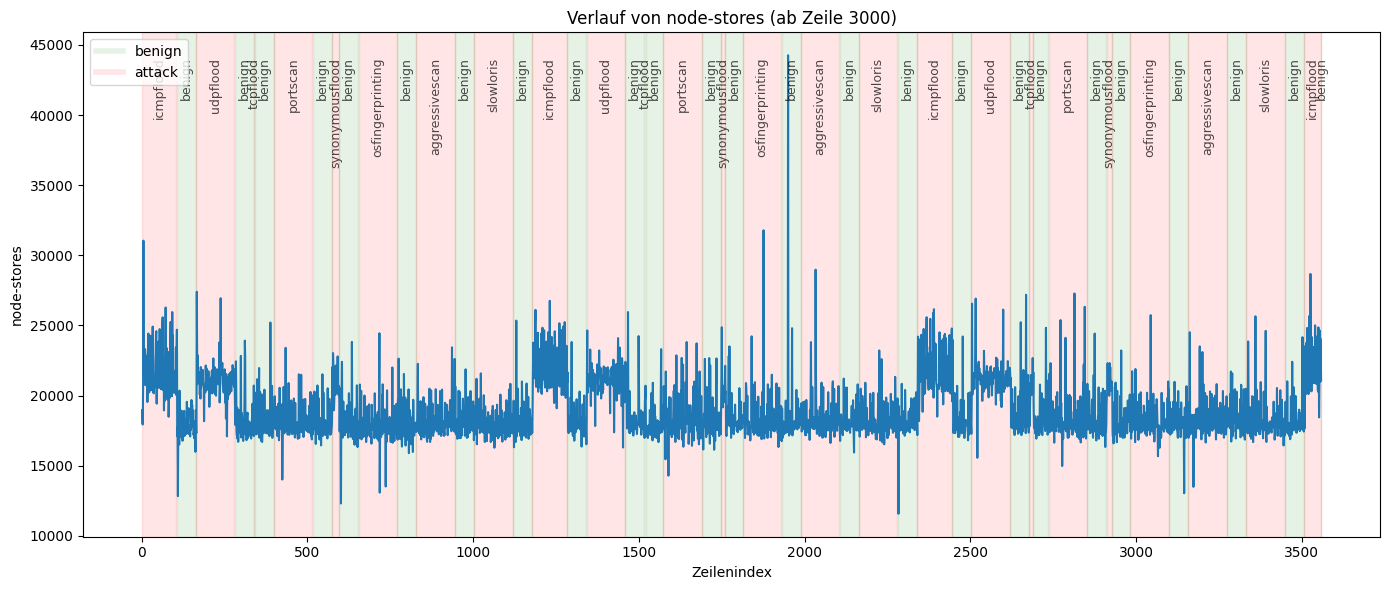

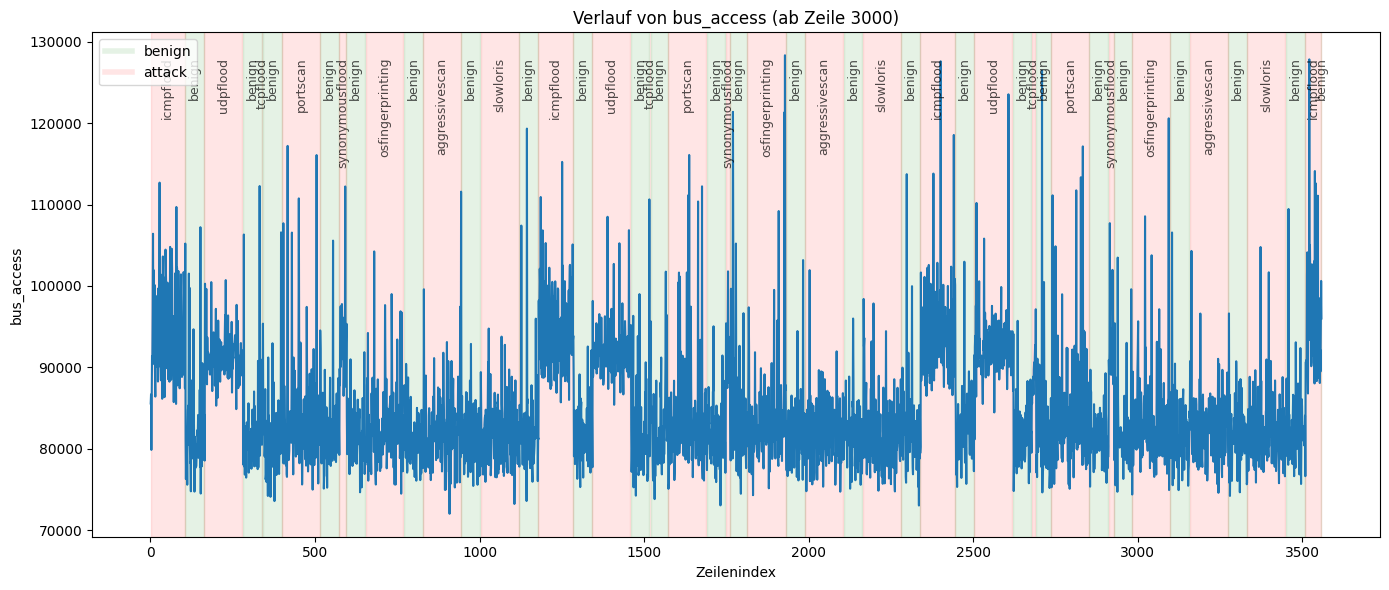

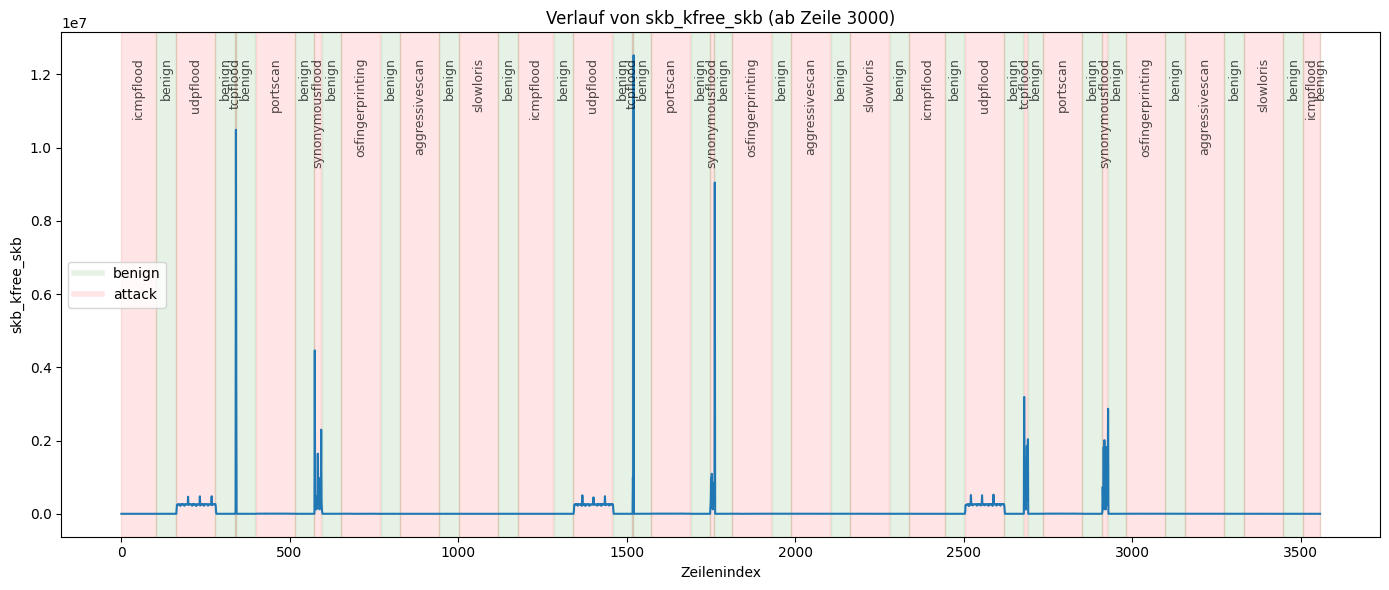

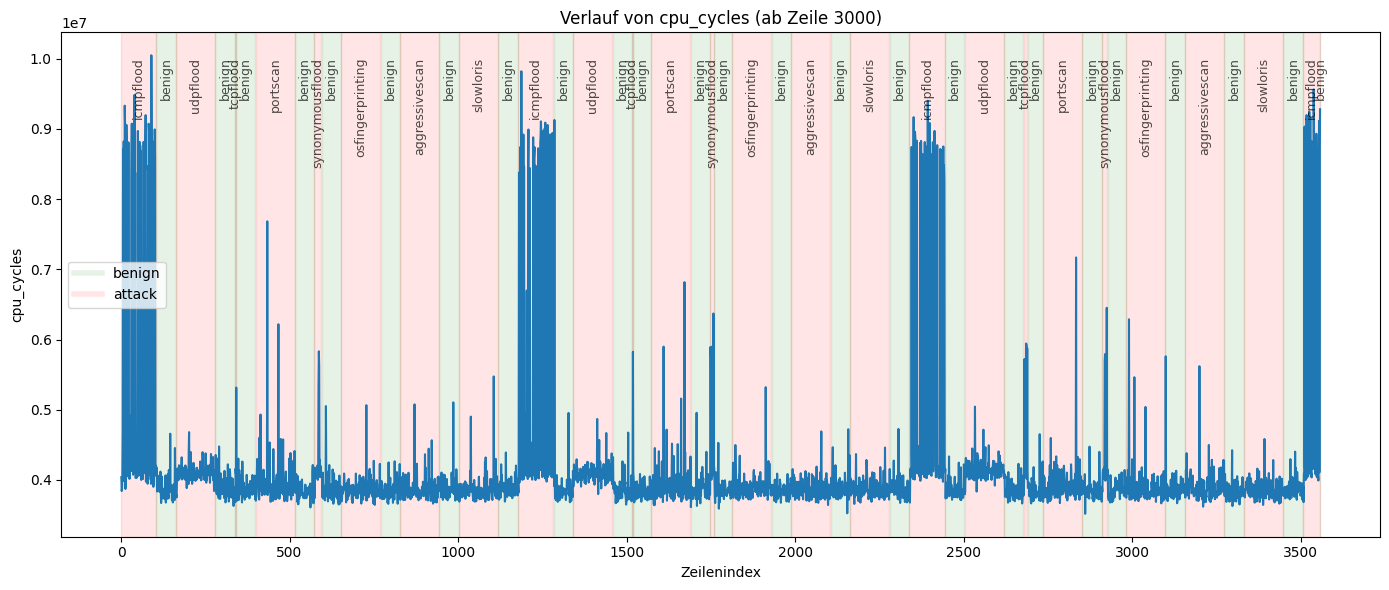

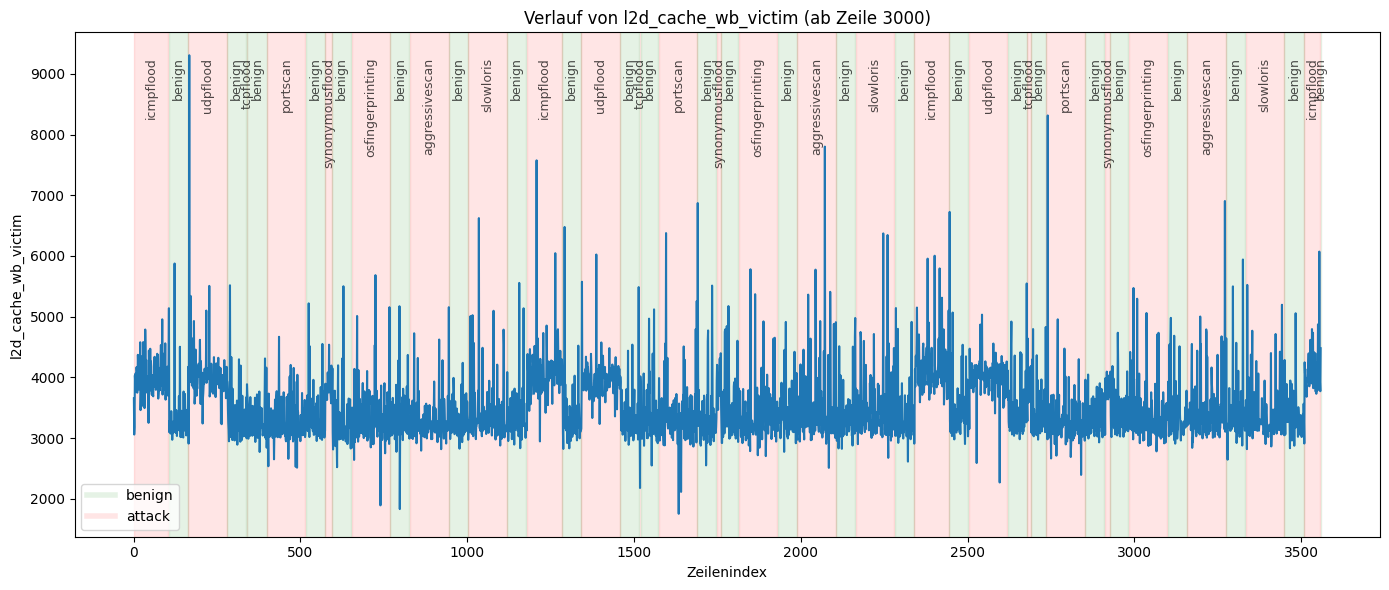

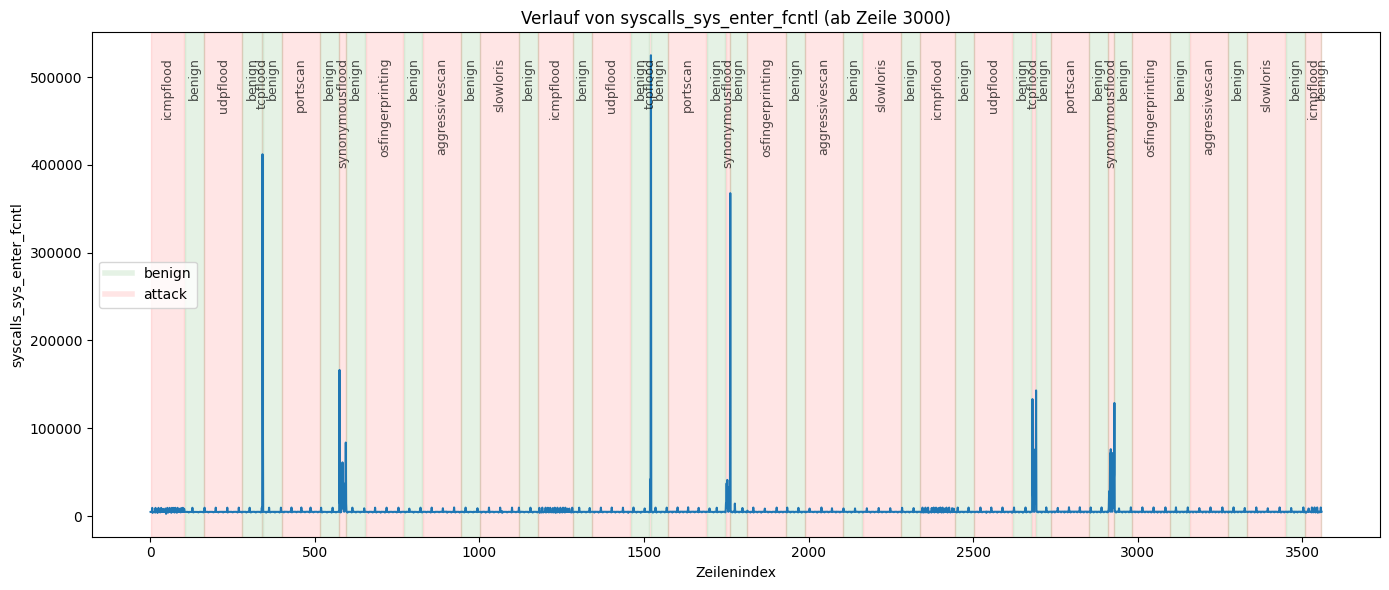

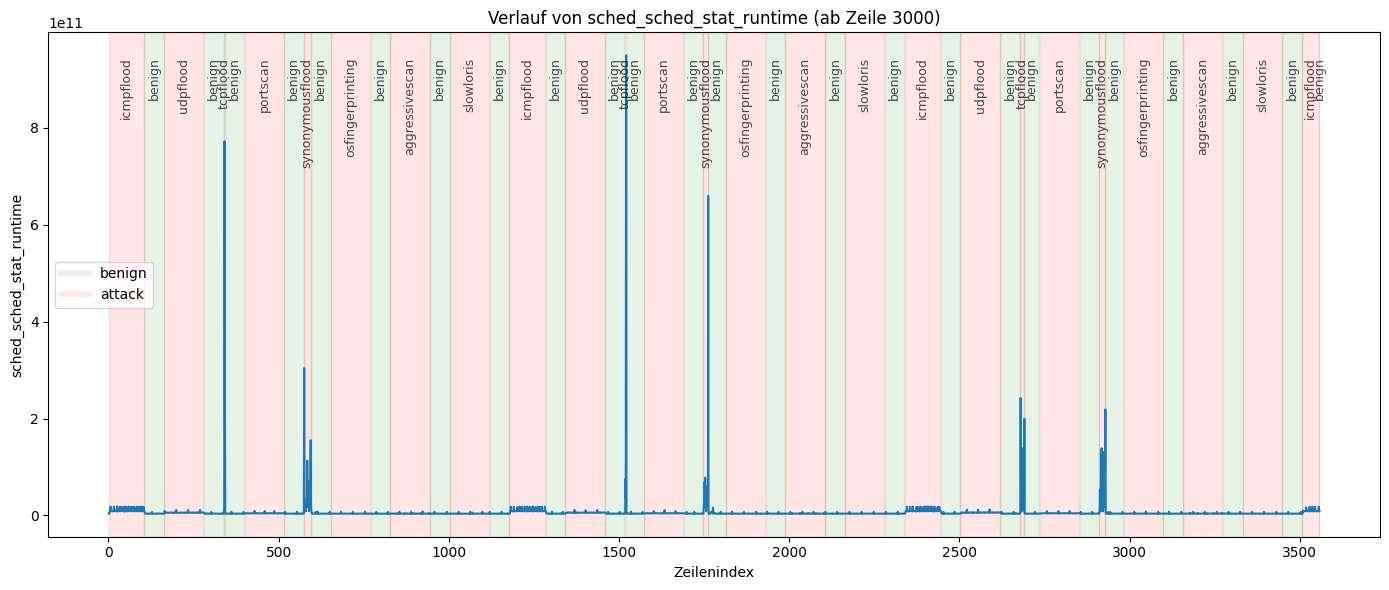

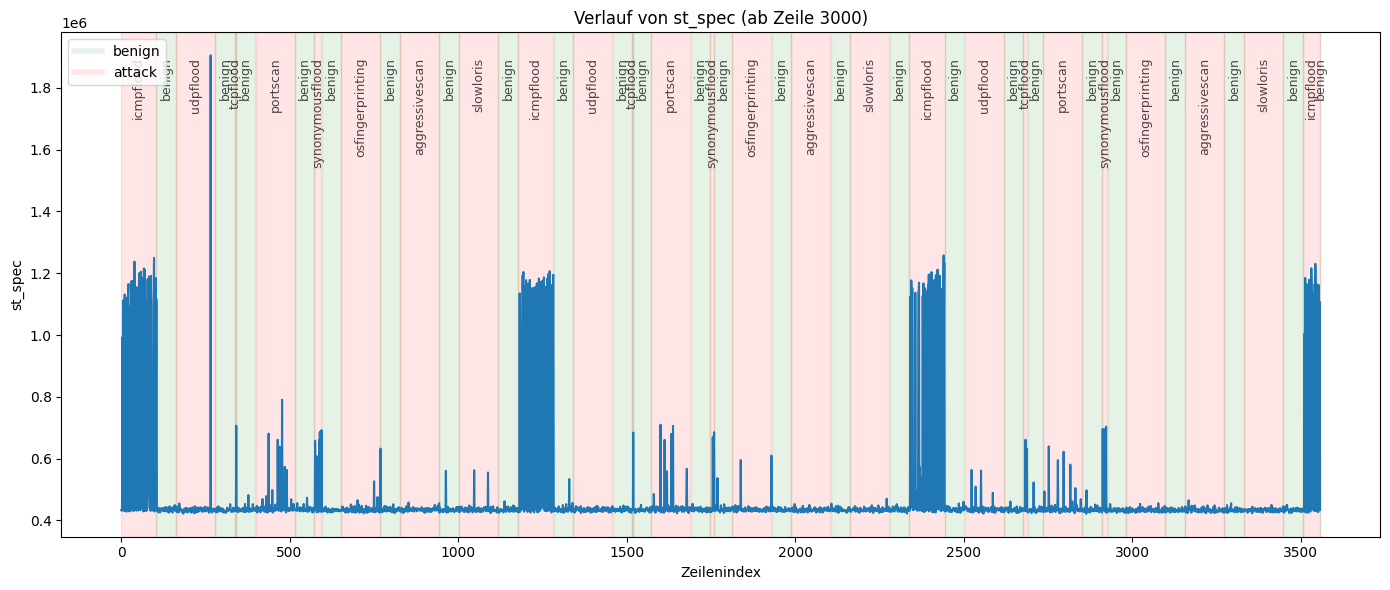

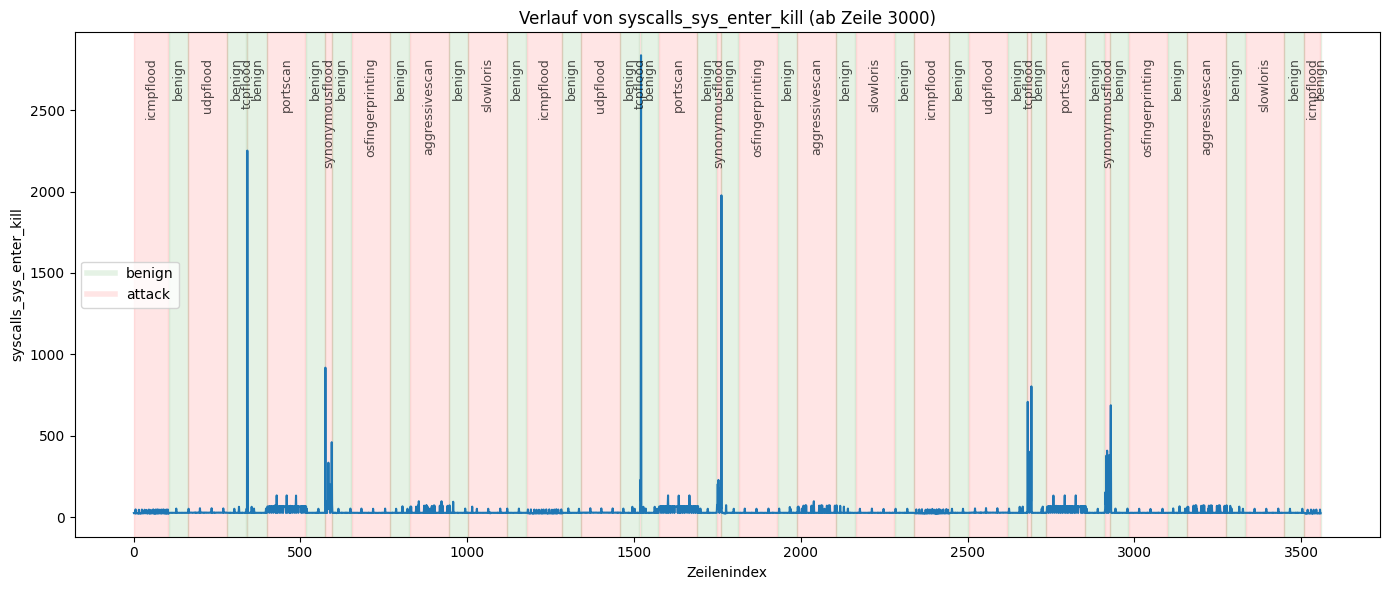

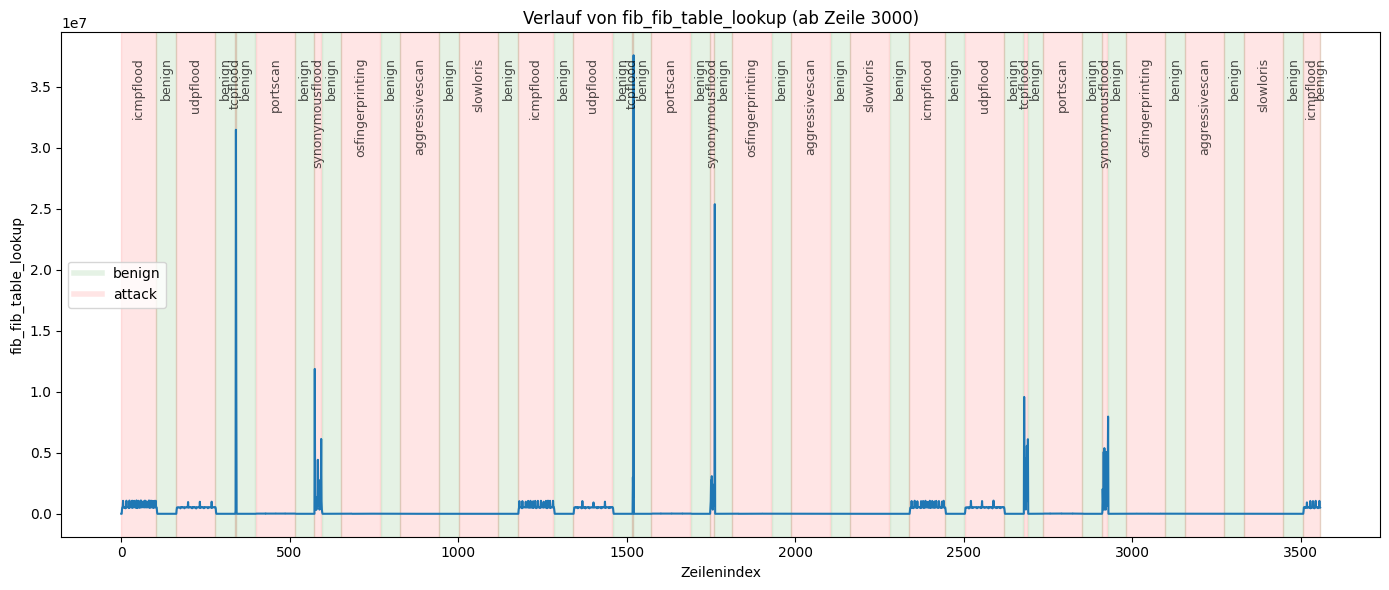

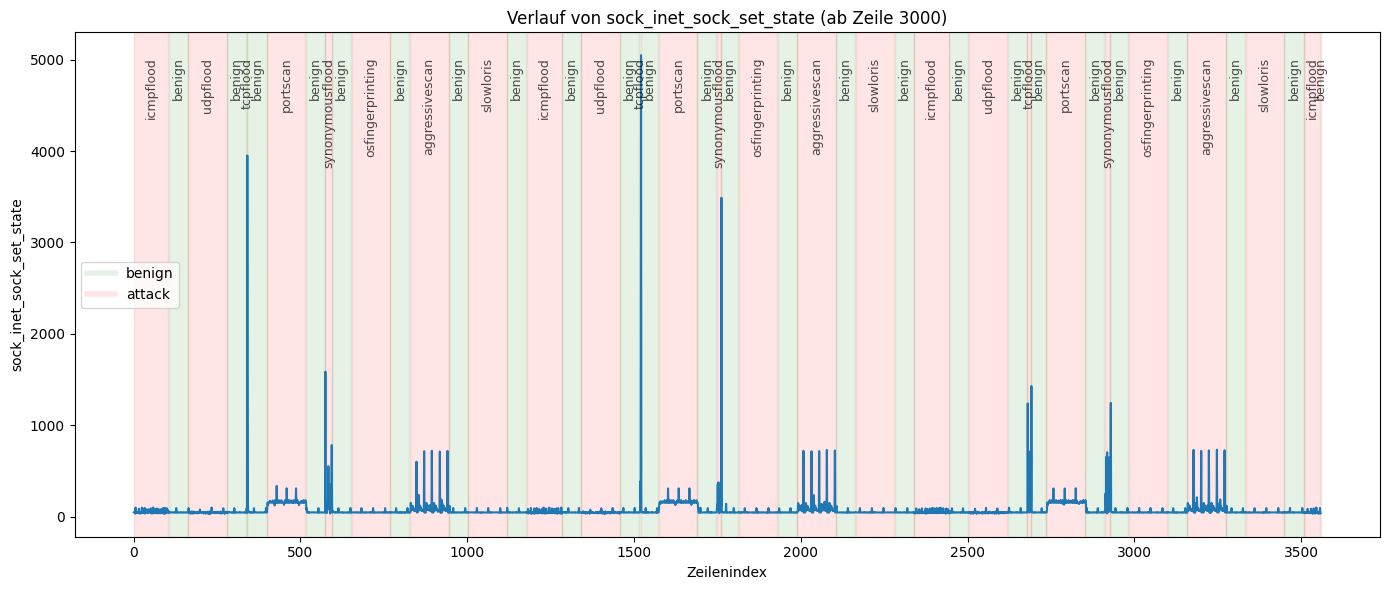

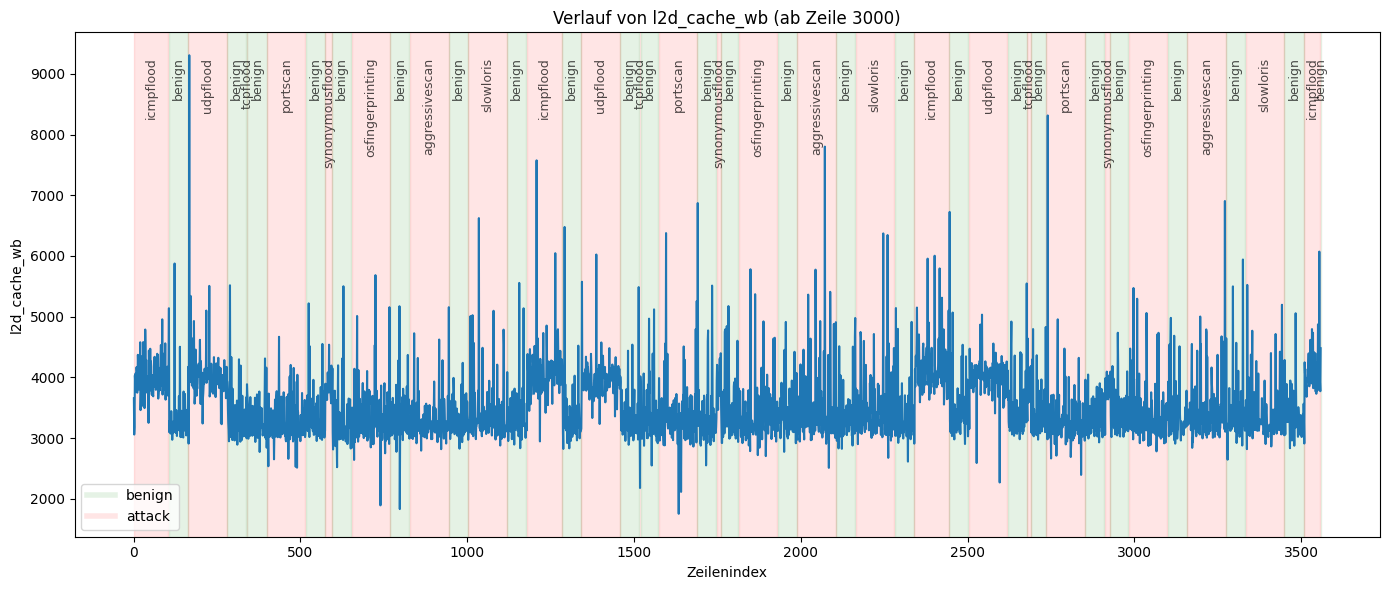

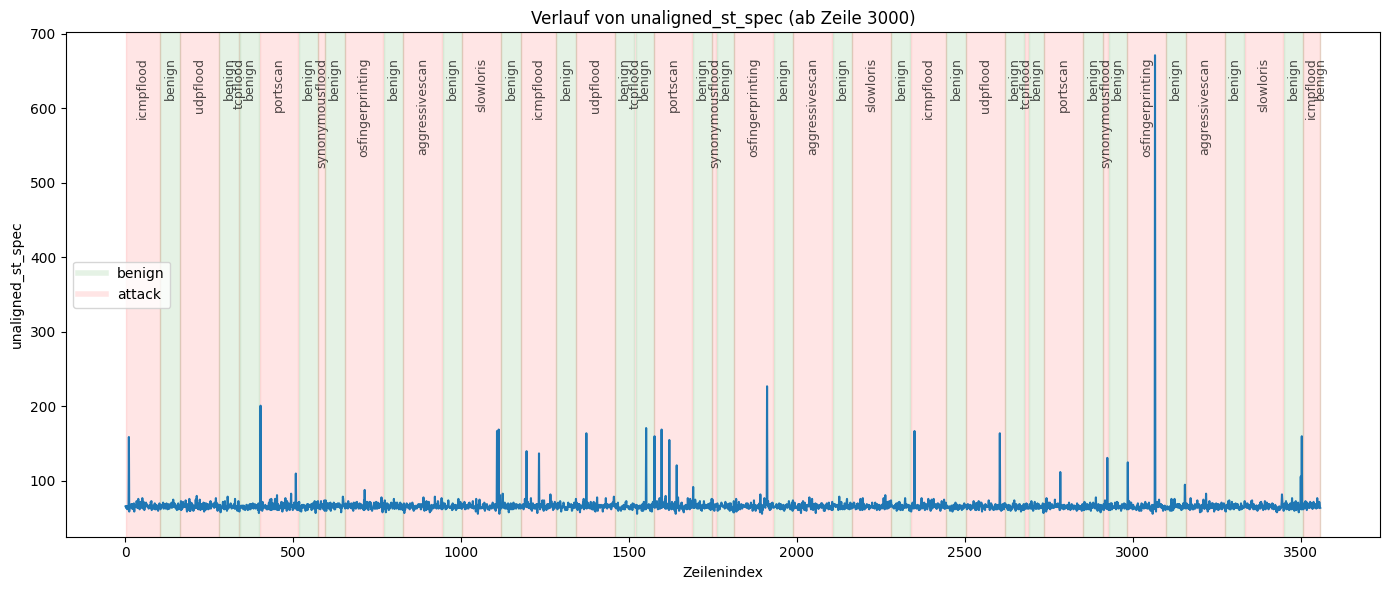

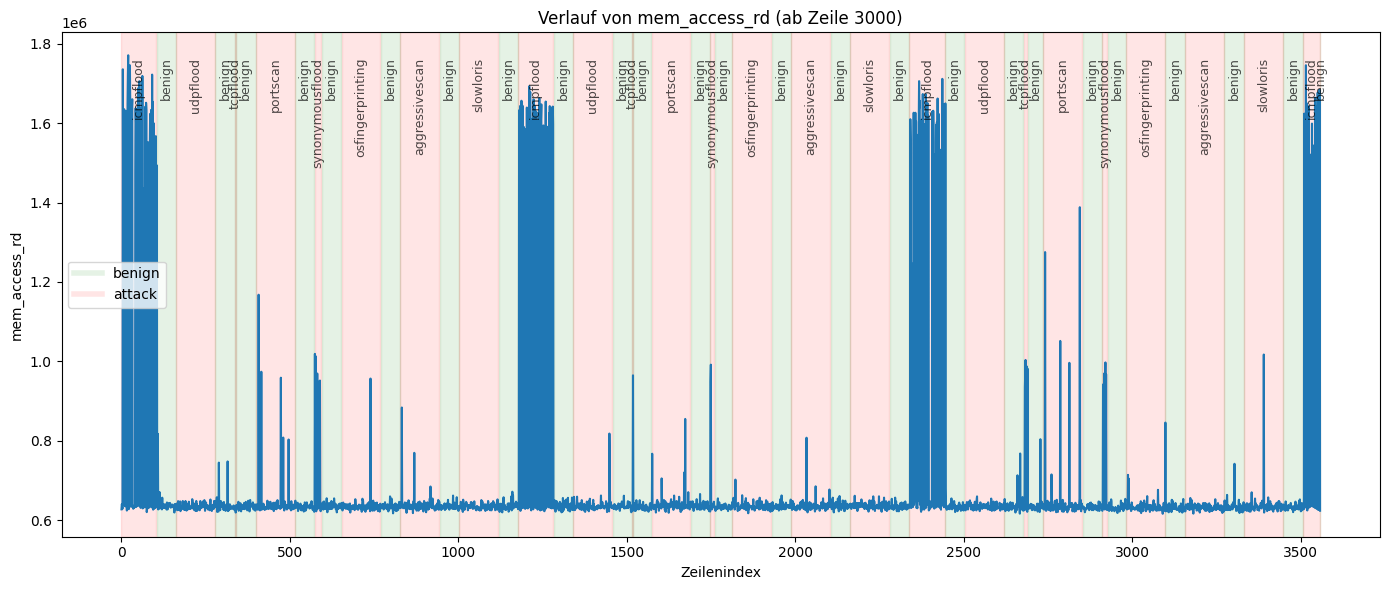

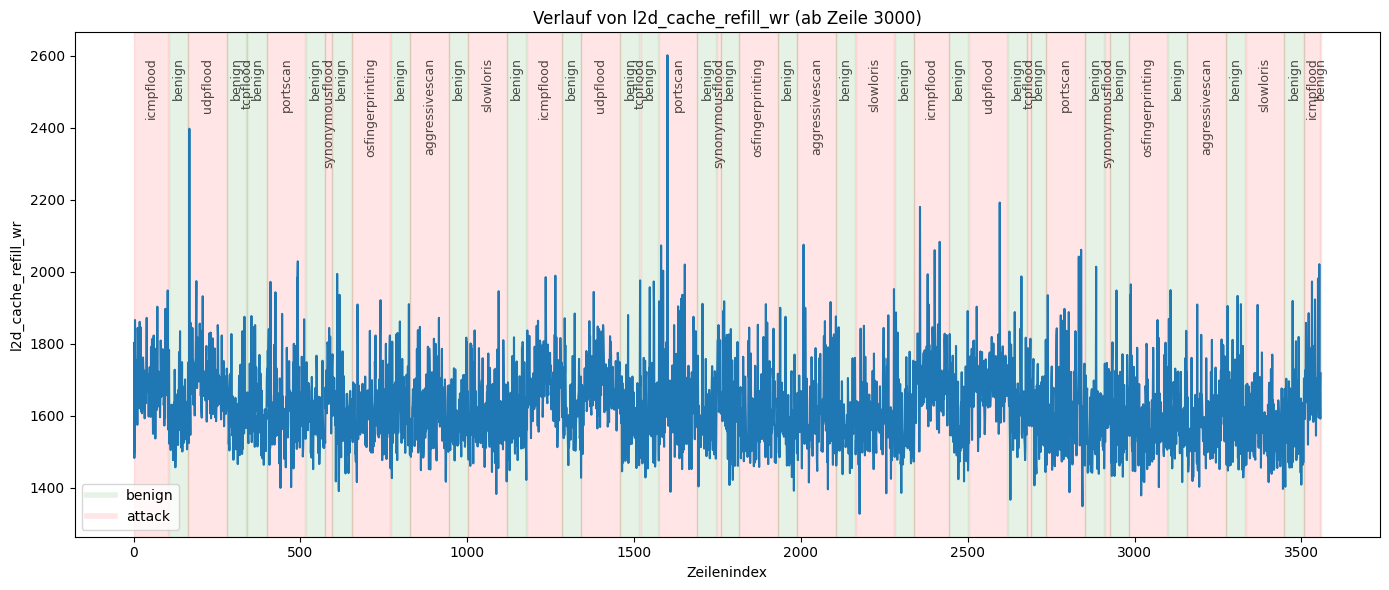

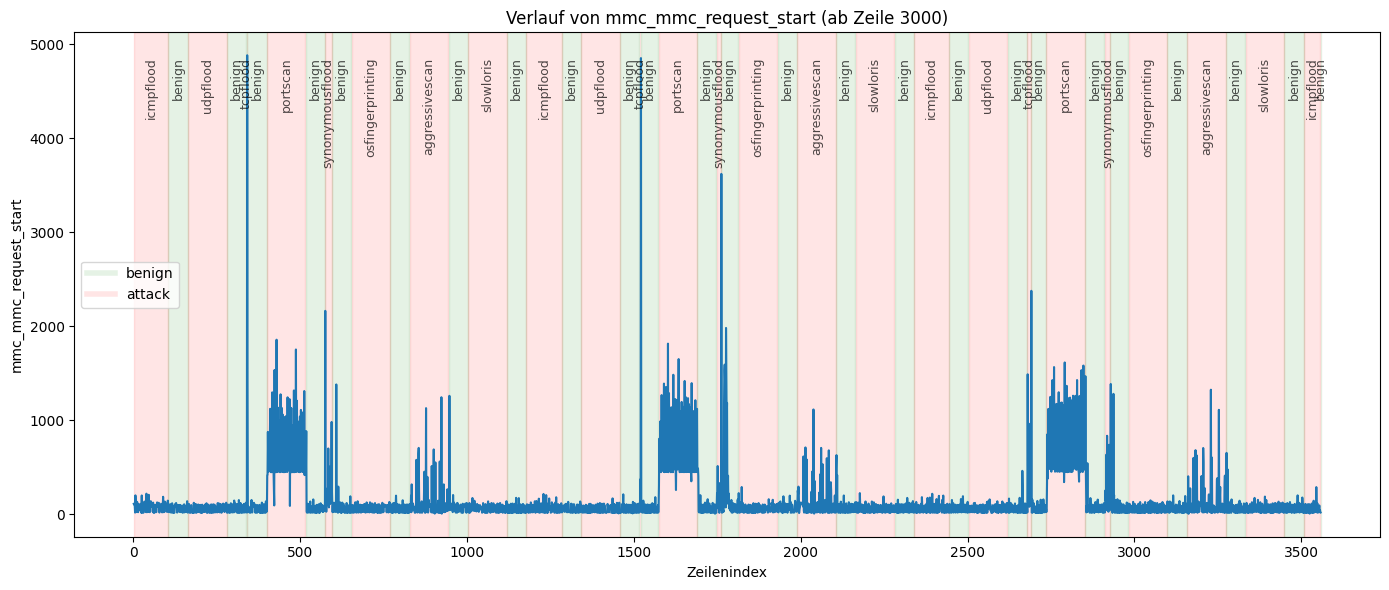

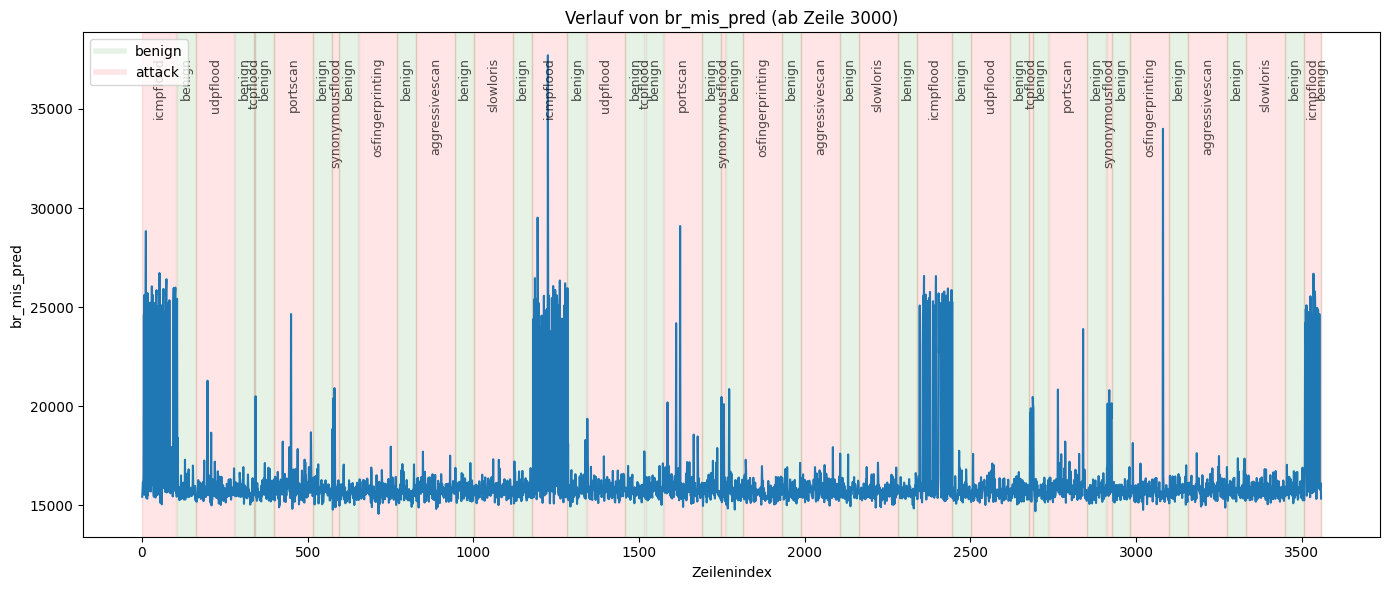

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = top20_features[:20]

for feat in selected_features:
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df[feat], label=feat)
    
    ymin, ymax = plt.ylim()
    start_idx = 0
    current_label = df['Label'].iloc[0]
    current_attack = df['attack'].iloc[0]

    for i in range(1, len(df)):
        label_changed = df['Label'].iloc[i] != current_label
        attack_changed = df['attack'].iloc[i] != current_attack
        if label_changed or attack_changed:
            color = 'green' if current_label == 'benign' else 'red'
            plt.axvspan(df.index[start_idx], df.index[i-1], color=color, alpha=0.1)
            mid_pos = (df.index[start_idx] + df.index[i-1]) / 2
            plt.text(
                mid_pos,
                ymax - (ymax - ymin) * 0.05,
                current_attack,
                ha='center',
                va='top',
                fontsize=9,
                color='black',
                alpha=0.7,
                rotation=90
            )
            start_idx = i
            current_label = df['Label'].iloc[i]
            current_attack = df['attack'].iloc[i]

    # Letztes Segment einfärben und beschriften
    color = 'green' if current_label == 'benign' else 'red'
    plt.axvspan(df.index[start_idx], df.index[-1], color=color, alpha=0.1)
    mid_pos = (df.index[start_idx] + df.index[-1]) / 2
    plt.text(
        mid_pos,
        ymax - (ymax - ymin) * 0.05,
        current_attack,
        ha='center',
        va='top',
        fontsize=9,
        color='black',
        alpha=0.7,
        rotation=90
    )

    plt.title(f'Verlauf von {feat} (ab Zeile 3000)')
    plt.xlabel('Zeilenindex')
    plt.ylabel(feat)
    handles = [
        plt.Line2D([0], [0], color='green', lw=4, alpha=0.1, label='benign'),
        plt.Line2D([0], [0], color='red', lw=4, alpha=0.1, label='attack')
    ]
    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()


In [16]:
import pandas as pd

# Nur echte Angriffe
true_attacks = df[df['Label'] != 'benign']
grouped = true_attacks.groupby('attack')

results = []

for attack_type, group in grouped:
    total = len(group)
    correct = (group['prediction'] == 1).sum()
    recall = correct / total if total > 0 else 0
    avg_prob = group['attack_prob'].mean()
    
    results.append({
        'Attack': attack_type,
        'Anzahl Angriffe': total,
        'Richtig erkannt': correct,
        'Recall': recall,
        'Ø attack_prob': avg_prob
    })

# Angriffsstatistik-DataFrame
attack_stats_df = pd.DataFrame(results)
attack_stats_df = attack_stats_df.sort_values(by='Recall', ascending=False)

# Durchschnitt attack_prob bei benign
avg_attack_prob_benign = df[df['Label'] == 'benign']['attack_prob'].mean()

# Ausgabe
print(attack_stats_df.to_string(index=False, float_format="%.4f"))
print(f"\nDurchschnittlicher 'attack_prob'-Wert bei benignem Traffic: {avg_attack_prob_benign:.4f}")


          Attack  Anzahl Angriffe  Richtig erkannt  Recall  Ø attack_prob
        udpflood              350              346  0.9886         0.9786
       icmpflood              366              356  0.9727         0.9504
 synonymousflood               51               46  0.9020         0.8479
        tcpflood               17               12  0.7059         0.6571
        portscan              349               79  0.2264         0.3635
osfingerprinting              349               24  0.0688         0.2936
  aggressivescan              350               24  0.0686         0.2823
       slowloris              350               11  0.0314         0.2791

Durchschnittlicher 'attack_prob'-Wert bei benignem Traffic: 0.2810


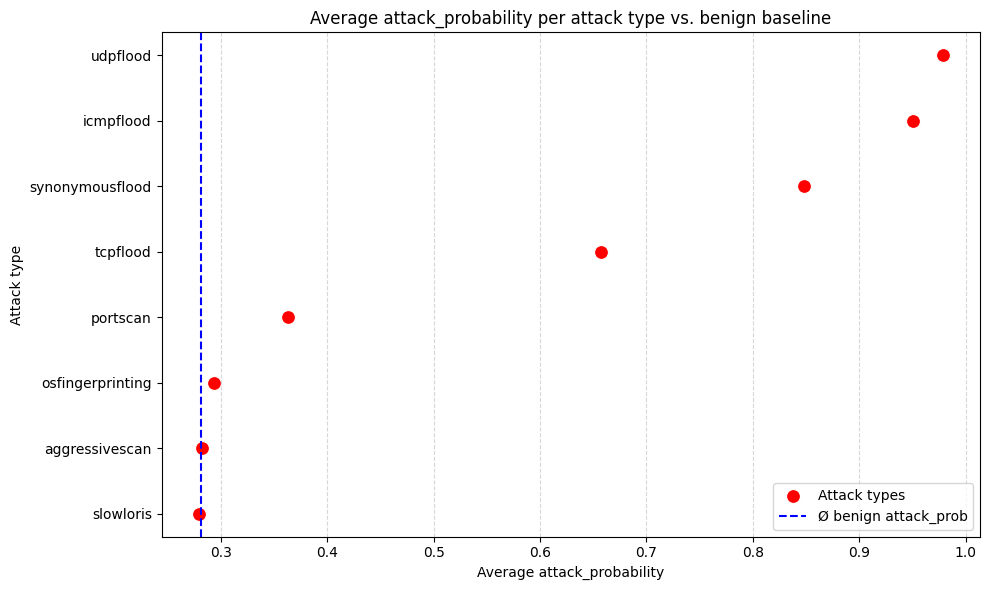

In [19]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Attack types
sns.scatterplot(
    data=attack_stats_df,
    x='Ø attack_prob',
    y='Attack',
    color='red',
    label='Attack types',
    s=100
)

# Average benign value as vertical line
plt.axvline(avg_attack_prob_benign, color='blue', linestyle='--', label='Ø benign attack_prob')

plt.title('Average attack_probability per attack type vs. benign baseline')
plt.xlabel('Average attack_probability')
plt.ylabel('Attack type')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
# Save the plot as PNG
output_dir = "/home/yannic/Desktop/Uni/Semester8_Regensburg/Bachelorarbeit/final_code/feature_plots"
filename = f"live_data_classification_results.png"
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300)
plt.show()
